In [32]:
# Step 1: Import the pandas library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [5]:
# Step 2: Load the CSV file
# Make sure the file is in the same folder as your notebook, or provide the full path
df = pd.read_csv('stores_sales_forecasting.csv', encoding='latin1')

# Step 3: Preview the data
print("First 5 Rows:")
print(df.head())

# Step 4: Check dataset structure
print("\n Dataset Info:")
print(df.info())

# Step 5: Check for missing values
print("\n Missing Values:")
print(df.isnull().sum())

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
3       6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
4      11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   

     Customer Name   Segment        Country             City  ... Postal Code  \
0      Claire Gute  Consumer  United States        Henderson  ...       42420   
1      Claire Gute  Consumer  United States        Henderson  ...       42420   
2   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...       33311   
3  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   
4  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   

   Region   

In [ ]:
# Exploratory Data Analysis

In [11]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# 1. Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

<Figure size 1000x600 with 0 Axes>

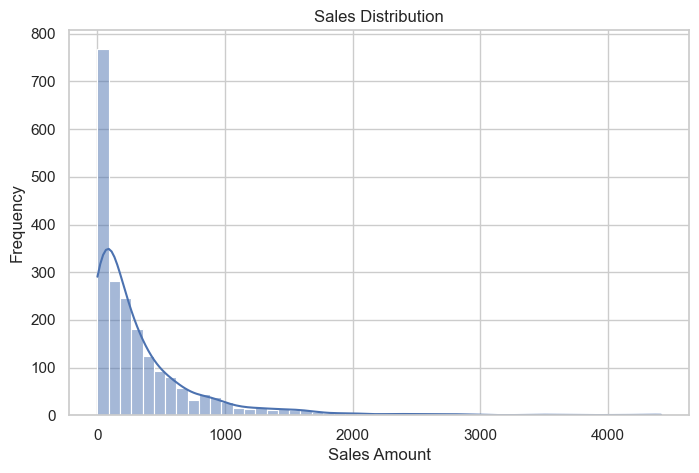

In [12]:
# 2. Distribution of Sales
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()

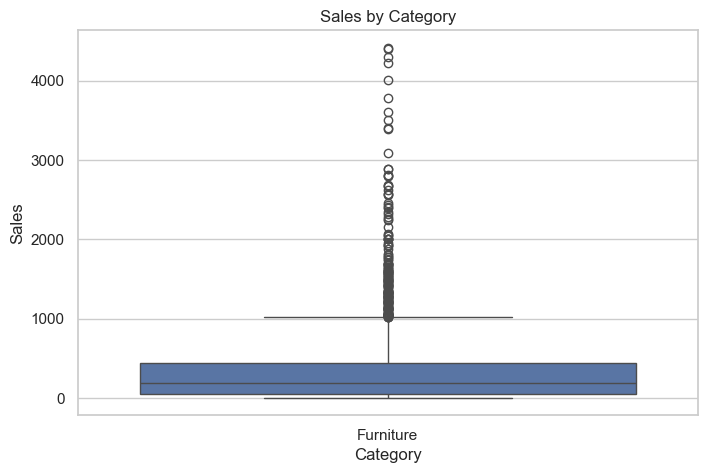

In [13]:
# 3. Sales by Category
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Category', y='Sales')
plt.title('Sales by Category')
plt.show()

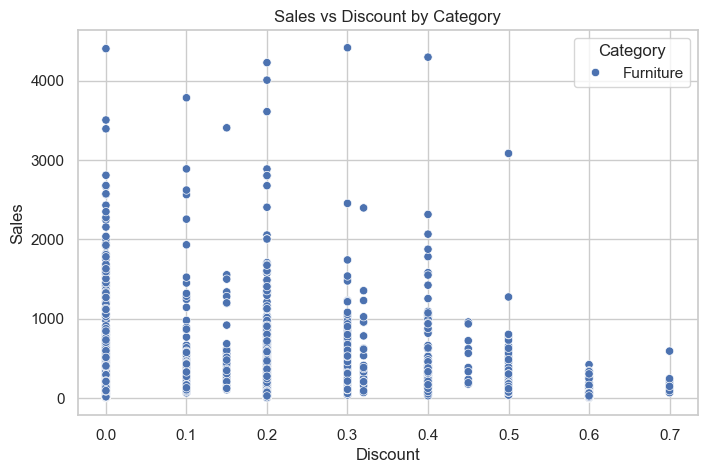

In [14]:
# 4. Sales vs. Discount
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Sales', hue='Category')
plt.title('Sales vs Discount by Category')
plt.show()

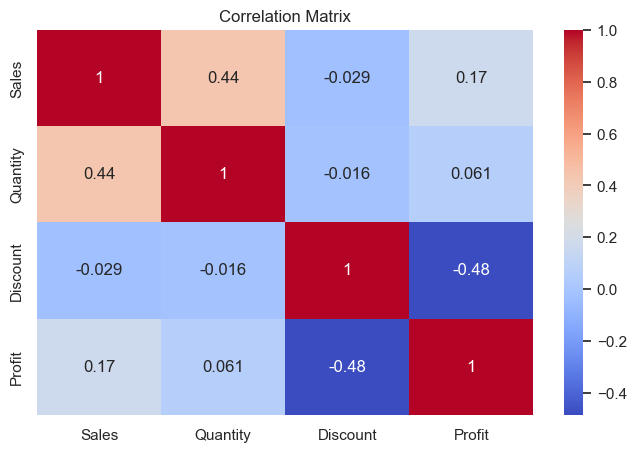

In [15]:
# 5. Correlation Matrix
plt.figure(figsize=(8,5))
sns.heatmap(df[['Sales', 'Quantity', 'Discount', 'Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Data Preprocessing

In [17]:
# Create new date-based features
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year'] = df['Order Date'].dt.year
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek  # Monday = 0

In [18]:
# Drop unnecessary columns (like ID columns, exact date columns, Customer Name, etc.)
df = df.drop(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Customer ID',
              'Customer Name', 'Country', 'City', 'State', 'Postal Code',
              'Product ID', 'Product Name'], axis=1)

In [19]:
# Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns

In [20]:
# Use Label Encoding for simplicity
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
# Final check
print("✅ Dataset after preprocessing:")
print(df.head())

✅ Dataset after preprocessing:
   Ship Mode  Segment  Region  Category  Sub-Category      Sales  Quantity  \
0          2        0       2         0             0   261.9600         2   
1          2        0       2         0             1   731.9400         3   
2          3        0       2         0             3   957.5775         5   
3          3        0       3         0             2    48.8600         7   
4          3        0       3         0             3  1706.1840         9   

   Discount    Profit  Order_Month  Order_Year  Order_DayOfWeek  
0      0.00   41.9136           11        2016                1  
1      0.00  219.5820           11        2016                1  
2      0.45 -383.0310           10        2015                6  
3      0.00   14.1694            6        2014                0  
4      0.20   85.3092            6        2014                0  


In [22]:
# Check final feature list
print("\n Final columns to be used for modeling:")
print(df.columns)


 Final columns to be used for modeling:
Index(['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Order_Month', 'Order_Year',
       'Order_DayOfWeek'],
      dtype='object')


In [24]:
#Model Training (Random Forest Regressor)

In [25]:
# 1. Separate features and target
X = df.drop('Sales', axis=1)
y = df['Sales']


In [26]:
# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 3. Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
# 4. Predict on test set
y_pred = model.predict(X_test)

In [29]:
# 5. Evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [30]:
# 6. Print results
print(" Model Evaluation Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

 Model Evaluation Metrics:
R² Score: 0.6987
RMSE: 303.83
MAE: 126.94


In [31]:
# Random Forest + Grid Search

In [33]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [34]:
# Initialize base model
rf = RandomForestRegressor(random_state=42)

In [35]:
# Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='r2', verbose=1)

In [36]:
# Fit the model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [37]:
# Best model
best_model = grid_search.best_estimator_

In [38]:
# Predict with best model
y_pred_best = best_model.predict(X_test)

In [39]:
# Evaluate
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

In [40]:
# Results
print(" Improved Model Performance:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

 Improved Model Performance:
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
R² Score: 0.7053
RMSE: 300.52
MAE: 122.69


In [41]:
#Plot Actual vs Predicted

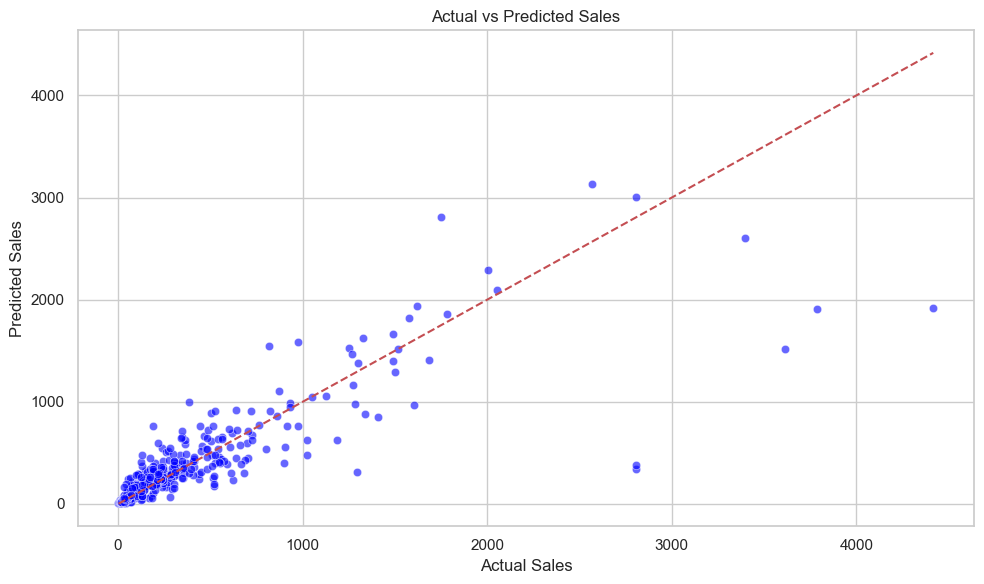

In [42]:
# Set the style
sns.set(style="whitegrid")

# Plot actual vs predicted
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # ideal line
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.tight_layout()
plt.show()

In [44]:
import joblib

# Save the trained model
joblib.dump(best_model, 'sales_forecast_model.pkl')

print("Model saved as 'sales_forecast_model.pkl'")

Model saved as 'sales_forecast_model.pkl'
